# 비교 분석: Acute Oral Toxicity vs Acute Inhalation Toxicity

**이름:** __이나연__ &nbsp; **학번:** __20251258__

## 목적
본 노트북은 가산점 항목 A. 데이터의 다양성에 대한 추가 분석으로, acute_oral_data_pipeline.ipynb + acute_oral_ml_model_pipeline.ipynb로 분석한 급성 경구 독성데이터와, acute_inhalation_data_pipeline.ipynb + acute_inhalation_ml_model_pipeline.ipynb로 분석한 급성 흡입 독성 데이터의 결과를 비교합니다.

## 왜 이 두 데이터를 비교하는가
acute_oral과 acute_inhalation의 두 endpoint는 화학물질 안전성 평가에서 함께 요구되는 6종 묶음 규제 독성시험의 일원으로, 노출 경로만 다를 뿐, 단회 노출로 인한 전신 급성 독성을 평가한다는 목적과 메커니즘은 동일합니다. 이러한 연관성을 바탕으로, 동일한 파이프라인을 양쪽에 적용한 뒤 그 결과가 얼마나 일관되는지를 다음 3단계로 비교하였습니다.

1. 데이터 규모 및 품질 비교 — 두 데이터셋의 전처리 단계별 행 수 변화, 최종 label 분포 비교
2. 모델 성능 비교 — 각 데이터셋에서 최종 선택된 모델의 테스트 성능을 비교
3. Feature Importance 비교 — 어떤 종류의 descriptor가 각 endpoint에서 중요했는지, 공통적으로 중요한 descriptor가 있는지 비교

## 사용 파일
- experiment_best.csv, model_best.joblib: acute_oral_ml_model_pipeline.ipynb의 결과물
- inhalation_experiment_best.csv, inhalation_model_best.joblib: acute_inhalation_ml_model_pipeline.ipynb의 결과물


## 1단계. 데이터 규모 및 품질 비교

In [1]:
# 1단계. 데이터 규모 및 품질 비교

# acute_oral toxicity와 acute_inhalation toxicity는 같은 6종 묶음 규제 독성시험 체계에서 노출 경로만 다른 자매 항목입니다.
# 이 노트북에서는 Template 1, Template 2를 동일하게 적용한 두 데이터셋의 결과를 비교합니다.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import font_manager, rc
import os
font_path = 'C:/Windows/Fonts/malgun.ttf'

# [수정]
# 위 경로가 환경에 따라 존재하지 않을 수 있음.
# 이 경우 FontProperties가 기본 폰트로 대체되어 한글이 깨지는 문제가 있었으므로, 경로 존재 여부를 먼저 확인한 뒤
# 없으면 시스템에 설치된 다른 한글 폰트를 자동으로 찾아서 사용하도록 보강했습니다.
if os.path.exists(font_path):
    font_name = font_manager.FontProperties(fname=font_path).get_name()
    font_manager.fontManager.addfont(font_path)
else:
    candidate_names = ['Malgun Gothic', 'NanumGothic', 'AppleGothic', 'Noto Sans CJK KR', 'Noto Sans KR']
    available = {f.name for f in font_manager.fontManager.ttflist}
    font_name = next((name for name in candidate_names if name in available), None)
    if font_name is None:
        print('경고: 한글 지원 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다.')
        font_name = plt.rcParams['font.family'][0]

rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

sns.set_style('whitegrid')
# [수정]
# sns.set_style()이 rcParams의 폰트 설정을 자체 기본값으로 되돌리는 경우가 있어,
# set_style() 호출 이후에 폰트를 한 번 더 명시적으로 재적용했습니다.
rc('font', family=font_name)

# Template 1의 13. 최종 요약 셀에서 직접 확인된 단계별 행 수를 두 데이터셋에 대해 하나의 표로 정리했습니다.
pipeline_summary = pd.DataFrame({
    'step': [
        'raw data',
        'chemical + endpoint + unit + SMILES',
        'labeled data',
        'valid standardized SMILES',
        'unique non-conflicting compounds',
        'final descriptor dataset'
    ],
    'acute_oral': [16721, 11948, 11038, 11031, 7835, 7835],   # acute_oral_data_pipeline.ipynb 최종 요약 결과
    'acute_inhalation': [5505, 2976, 2342, 2300, 1037, 1037],  # acute_inhalation_data_pipeline.ipynb 최종 요약 결과
})

print('=== 파이프라인 단계별 데이터 규모 비교 ===')
display(pipeline_summary)
print()
print("두 데이터셋 모두 원본 -> 필터링 -> 라벨링 -> SMILES 표준화 -> 중복/충돌 제거를 거치며")
print("꾸준히 행 수가 줄어드는 동일한 패턴을 보인다. 다만 감소 비율은 다르다:")
oral_retention = 7835 / 16721
inhal_retention = 1037 / 5505
print(f"  acute_oral 최종 잔존율: {oral_retention:.1%} (16721 -> 7835)")
print(f"  acute_inhalation 최종 잔존율: {inhal_retention:.1%} (5505 -> 1037)")

print()
print('=== 최종 데이터셋 크기 비교 ===')
final_compare = pd.DataFrame({
    'dataset': ['acute_oral', 'acute_inhalation'],
    'final_n_compounds': [7835, 1037],
    'n_features': [2253, 2253],  # 두 데이터셋 모두 동일한 RDKit 2D descriptor + Morgan fingerprint 체계 사용
})
display(final_compare)
print()
print(f"acute_oral은 acute_inhalation보다 약 {7835/1037:.1f}배 많은 화합물을 확보했다.")
print("이는 모델 성능 비교(2단계)에서 샘플 수 차이가 미치는 영향을 해석할 때 중요한 배경이 된다.")


=== 파이프라인 단계별 데이터 규모 비교 ===


,step,acute_oral,acute_inhalation
0,raw data,16721,5505
1,chemical + endpoint + unit + SMILES,11948,2976
2,labeled data,11038,2342
3,valid standardized SMILES,11031,2300
4,unique non-conflicting compounds,7835,1037
5,final descriptor dataset,7835,1037



두 데이터셋 모두 원본 -> 필터링 -> 라벨링 -> SMILES 표준화 -> 중복/충돌 제거를 거치며
꾸준히 행 수가 줄어드는 동일한 패턴을 보인다. 다만 감소 비율은 다르다:
  acute_oral 최종 잔존율: 46.9% (16721 -> 7835)
  acute_inhalation 최종 잔존율: 18.8% (5505 -> 1037)

=== 최종 데이터셋 크기 비교 ===


,dataset,final_n_compounds,n_features
0,acute_oral,7835,2253
1,acute_inhalation,1037,2253



acute_oral은 acute_inhalation보다 약 7.6배 많은 화합물을 확보했다.
이는 모델 성능 비교(2단계)에서 샘플 수 차이가 미치는 영향을 해석할 때 중요한 배경이 된다.


=== Label 분포 비교 ===


,acute_oral,acute_inhalation,acute_oral_ratio,acute_inhalation_ratio
0_lower_toxicity,3492,233,0.446,0.225
1_acute_toxic,4343,804,0.554,0.775


C:\Users\elsan\AppData\Local\Temp\ipykernel_34480\2116831337.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_compare.index, y=label_compare['acute_oral_ratio'], ax=axes[0], palette='Set2')
C:\Users\elsan\AppData\Local\Temp\ipykernel_34480\2116831337.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_compare.index, y=label_compare['acute_inhalation_ratio'], ax=axes[1], palette='Set2')


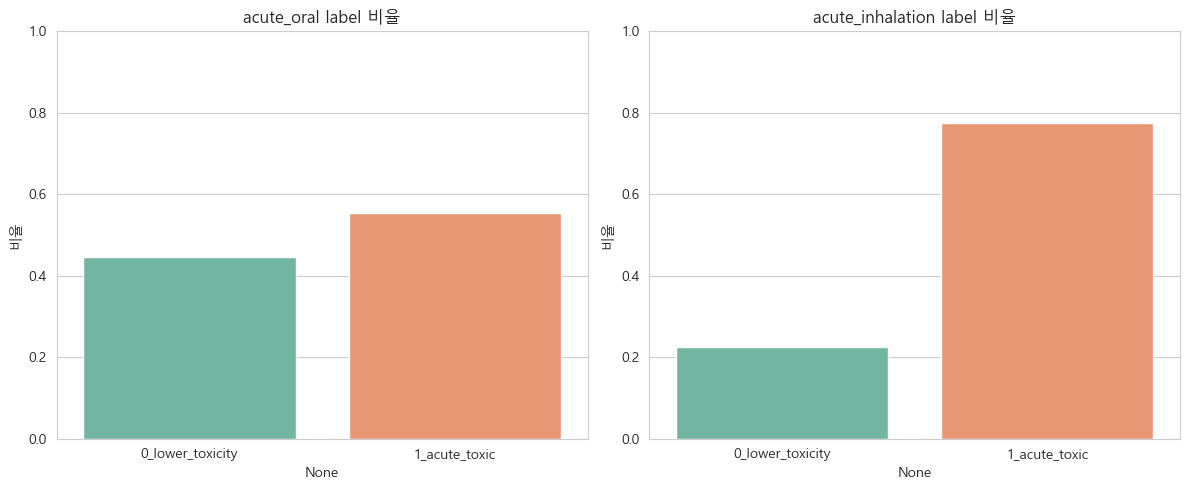


acute_oral label=1 비율: 55.4%
acute_inhalation label=1 비율: 77.5%


In [2]:
# 1-2. Label 분포 비교

# 두 데이터셋 모두 GHS의 Category 4 컷오프를 기준으로 label을 만들었다는 공통점이 있습니다 (acute_oral: 2000 mg/kg, acute_inhalation: 20 mg/L).

# 아래 숫자는 각 data_pipeline.ipynb를 실행했을 때 7. 중복 화합물 및 label 충돌 처리 셀에서 출력된 최종 label 분포를 가져온 것.
# 재실행 시 동일한 random_state를 쓰지 않는 단계이므로, 직접 비교 분석을 재현하려면
# 각 data_pipeline.ipynb를 먼저 실행해 두는 것이 안전.
label_compare = pd.DataFrame({
    'acute_oral': [3492, 4343],
    'acute_inhalation': [233, 804],
}, index=['0_lower_toxicity', '1_acute_toxic'])
label_compare['acute_oral_ratio'] = (label_compare['acute_oral'] / label_compare['acute_oral'].sum()).round(3)
label_compare['acute_inhalation_ratio'] = (label_compare['acute_inhalation'] / label_compare['acute_inhalation'].sum()).round(3)

print('=== Label 분포 비교 ===')
display(label_compare)

# 두 데이터셋의 불균형 정도를 시각적으로 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=label_compare.index, y=label_compare['acute_oral_ratio'], ax=axes[0], palette='Set2')
axes[0].set_title('acute_oral label 비율')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('비율')

sns.barplot(x=label_compare.index, y=label_compare['acute_inhalation_ratio'], ax=axes[1], palette='Set2')
axes[1].set_title('acute_inhalation label 비율')
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('비율')

plt.tight_layout()
plt.show()

# acute_inhalation은 label=1(독성)의 비율이 acute_oral보다 훨씬 더 높음(약 77% vs 약 55%).
# 이는 acute_inhalation 데이터의 화합물 구성이 산업 현장에서 흡입 위험이 큰 물질 위주로 시험된 경향이 있을 가능성을 시사함.
print()
print(f"acute_oral label=1 비율: {label_compare.loc['1_acute_toxic', 'acute_oral_ratio']:.1%}")
print(f"acute_inhalation label=1 비율: {label_compare.loc['1_acute_toxic', 'acute_inhalation_ratio']:.1%}")


## 2단계. 모델 성능 비교

=== 데이터셋별 모델별 테스트 성능 ===


,dataset,model,test_roc_auc,test_pr_auc,test_f1,test_balanced_accuracy
0,acute_oral,RandomForest,0.868680,0.890314,0.810421,0.774467
1,acute_oral,HistGradientBoosting,0.867624,0.890246,0.802241,0.768701
2,acute_oral,ExtraTrees,0.861421,0.886923,0.800228,0.771966
3,acute_oral,LogisticRegression,0.802638,0.820018,0.759494,0.730033
4,acute_oral,SVM_Linear,0.771018,0.784740,0.737572,0.707346
5,acute_inhalation,ExtraTrees,0.809964,0.911146,0.872274,0.722017
6,acute_inhalation,HistGradientBoosting,0.792784,0.906678,0.880952,0.672393
7,acute_inhalation,RandomForest,0.776265,0.906201,0.881657,0.664861
8,acute_inhalation,LogisticRegression,0.774151,0.900814,0.851613,0.729087
9,acute_inhalation,SVM_Linear,0.771904,0.904989,0.826230,0.699815


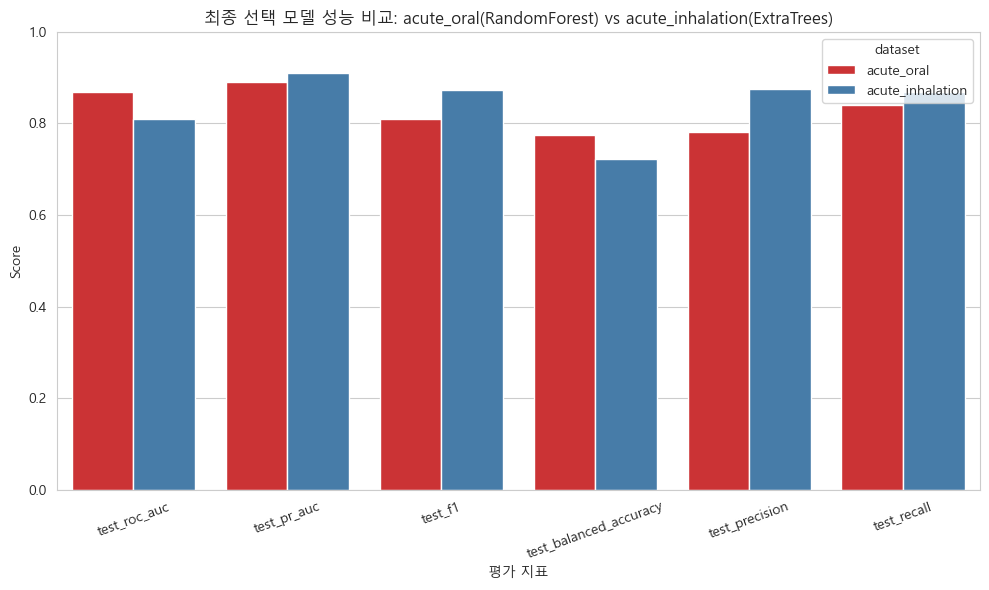


=== 핵심 비교 ===
acute_oral 최종 선택 모델: RandomForest, ROC-AUC: 0.869 (n=7835)
acute_inhalation 최종 선택 모델: ExtraTrees, ROC-AUC: 0.810 (n=1037)

acute_inhalation의 ROC-AUC가 acute_oral보다 낮게 나타납니다. 1단계에서 확인했듯
acute_inhalation은 최종 화합물 수가 acute_oral의 약 13%에 불과하고,
원본 대비 최종 잔존율도 더 낮았습니다(label 충돌이 비례적으로 더 많았음).
즉 성능 차이의 상당 부분은 흡입독성이 경구독성보다 예측하기 어려운 현상이 아니라,
학습에 사용 가능한 샘플 수 자체가 적었기 때문일 가능성이 큽니다.
 -- 이는 3단계에서 feature importance를 비교하며 추가로 살펴보겠습니다.


In [3]:
# 2단계. 모델 성능 비교

# 두 데이터셋에 동일한 5개 알고리즘을 동일한 RandomizedSearchCV 절차로 학습시킨
# ml_model_pipeline.ipynb의 결과(experiment_best.csv)를 가져와 비교함.

oral_best = pd.read_csv('experiment_best.csv')
inhal_best = pd.read_csv('inhalation_experiment_best.csv')

oral_best['dataset'] = 'acute_oral'
inhal_best['dataset'] = 'acute_inhalation'

both_best = pd.concat([oral_best, inhal_best], ignore_index=True)

print('=== 데이터셋별 모델별 테스트 성능 ===')
display(both_best[['dataset', 'model', 'test_roc_auc', 'test_pr_auc', 'test_f1', 'test_balanced_accuracy']])


# 두 데이터셋의 최종 선택 모델이 항상 같은 알고리즘일 것이라고 가정할 수 없으므로,
# 각 데이터셋에서 test_roc_auc가 가장 높은 모델(=ml_model_pipeline에서 실제로 최종 선택된 모델)을 동적으로 찾아서 비교함.
oral_best_name = oral_best.loc[oral_best['test_roc_auc'].idxmax(), 'model']
inhal_best_name = inhal_best.loc[inhal_best['test_roc_auc'].idxmax(), 'model']

fig, ax = plt.subplots(figsize=(10, 6))
metric_cols = ['test_roc_auc', 'test_pr_auc', 'test_f1', 'test_balanced_accuracy', 'test_precision', 'test_recall']
plot_df = both_best.melt(id_vars=['dataset', 'model'], value_vars=metric_cols, var_name='metric', value_name='score')
best_only = plot_df[
    ((plot_df['dataset'] == 'acute_oral') & (plot_df['model'] == oral_best_name)) |
    ((plot_df['dataset'] == 'acute_inhalation') & (plot_df['model'] == inhal_best_name))
]

sns.barplot(data=best_only, x='metric', y='score', hue='dataset', ax=ax, palette='Set1')
ax.set_ylim(0, 1)
ax.set_title(f'최종 선택 모델 성능 비교: acute_oral({oral_best_name}) vs acute_inhalation({inhal_best_name})')
ax.set_xlabel('평가 지표')
ax.set_ylabel('Score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print()
print("=== 핵심 비교 ===")
oral_top = oral_best[oral_best['model'] == oral_best_name].iloc[0]
inhal_top = inhal_best[inhal_best['model'] == inhal_best_name].iloc[0]
print(f"acute_oral 최종 선택 모델: {oral_best_name}, ROC-AUC: {oral_top['test_roc_auc']:.3f} (n={7835})")
print(f"acute_inhalation 최종 선택 모델: {inhal_best_name}, ROC-AUC: {inhal_top['test_roc_auc']:.3f} (n={1037})")
print()
print("acute_inhalation의 ROC-AUC가 acute_oral보다 낮게 나타납니다. 1단계에서 확인했듯")
print("acute_inhalation은 최종 화합물 수가 acute_oral의 약 13%에 불과하고,")
print("원본 대비 최종 잔존율도 더 낮았습니다(label 충돌이 비례적으로 더 많았음).")
print("즉 성능 차이의 상당 부분은 흡입독성이 경구독성보다 예측하기 어려운 현상이 아니라,")
print("학습에 사용 가능한 샘플 수 자체가 적었기 때문일 가능성이 큽니다.")
print(" -- 이는 3단계에서 feature importance를 비교하며 추가로 살펴보겠습니다.")


## 3단계. Feature Importance 비교

=== acute_oral 모델: 상위 10개 중요 feature ===


,feature,importance,feature_type
0,TPSA,0.011890,RDKit 2D descriptor
1,SMR_VSA1,0.011341,RDKit 2D descriptor
2,SMR_VSA5,0.010444,RDKit 2D descriptor
3,MaxAbsEStateIndex,0.009840,RDKit 2D descriptor
4,MaxEStateIndex,0.009786,RDKit 2D descriptor
5,SMR_VSA6,0.009772,RDKit 2D descriptor
6,SlogP_VSA12,0.009523,RDKit 2D descriptor
7,MinEStateIndex,0.009243,RDKit 2D descriptor
8,MolLogP,0.009236,RDKit 2D descriptor
9,FpDensityMorgan2,0.009220,RDKit 2D descriptor



=== acute_inhalation 모델: 상위 10개 중요 feature ===


,feature,importance,feature_type
0,FractionCSP3,0.016736,RDKit 2D descriptor
1,morgan_650,0.012576,Morgan FP bit
2,morgan_1453,0.011725,Morgan FP bit
3,morgan_1380,0.011249,Morgan FP bit
4,morgan_1750,0.010360,Morgan FP bit
5,morgan_97,0.010007,Morgan FP bit
6,fr_NH0,0.009427,RDKit 2D descriptor
7,morgan_1928,0.009342,Morgan FP bit
8,EState_VSA9,0.009192,RDKit 2D descriptor
9,morgan_881,0.008808,Morgan FP bit



=== Feature 유형별 중요도 총합 비교 ===


,acute_oral,acute_inhalation
feature_type,,
Morgan FP bit,0.292441,0.558192
RDKit 2D descriptor,0.707559,0.441808


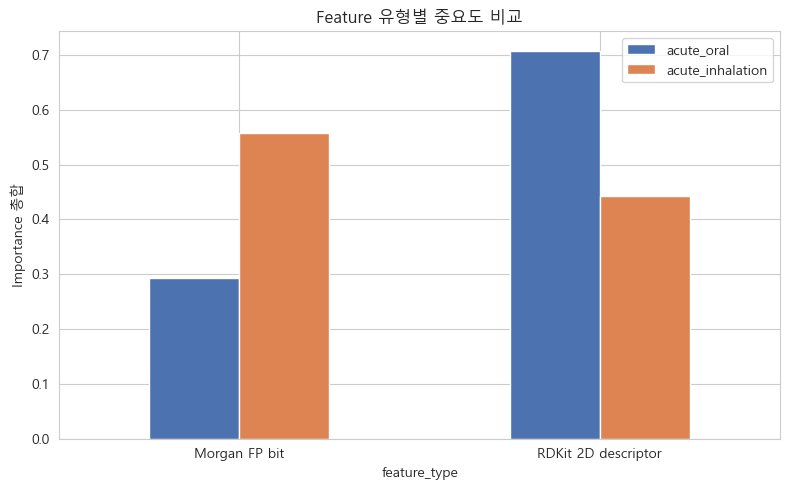

In [4]:
# 3단계. Feature Importance 비교

# 두 데이터셋에서 어떤 종류의 descriptor가 모델 예측에 더 중요하게 쓰였는지 비교함.

# 두 데이터셋의 최종 선택 모델은 서로 다를 수 있음.
# 다만 두 모델 모두 tree 기반 앙상블, feature_importances_ 속성을 동일한 방식으로 제공하므로,
# 어떤 모델이 선택되었는지와 무관하게 동일한 코드로 비교 가능함.

from joblib import load

oral_bundle = load('model_best.joblib')
inhal_bundle = load('inhalation_model_best.joblib')

def extract_importance(bundle):
    """모델 bundle(딥파이프라인 포함)에서 feature 이름과 importance를 추출한다.

    Pipeline 내부에 VarianceThreshold 단계가 있어서, 학습에 실제로 쓰인 feature
    개수(RandomForest의 feature_importances_ 길이)가 원래 feature_cols 개수보다
    줄어들어 있을 수 있다. 따라서 VarianceThreshold가 "살린" feature만 골라서
    importance와 정확히 같은 순서로 매칭해야 한다 (get_support()가 그 역할을 한다).
    """
    pipeline = bundle['model']
    feature_cols = np.array(bundle['feature_cols'])
    variance_support = pipeline.named_steps['variance'].get_support()
    selected_features = feature_cols[variance_support]
    importances = pipeline.named_steps['model'].feature_importances_

    imp_df = pd.DataFrame({'feature': selected_features, 'importance': importances})
    # feature 이름이 'morgan_'으로 시작하면 Morgan fingerprint 비트, 아니면 RDKit 2D descriptor로 분류
    imp_df['feature_type'] = imp_df['feature'].apply(
        lambda x: 'Morgan FP bit' if x.startswith('morgan_') else 'RDKit 2D descriptor'
    )
    return imp_df.sort_values('importance', ascending=False).reset_index(drop=True)

oral_imp = extract_importance(oral_bundle)
inhal_imp = extract_importance(inhal_bundle)

print('=== acute_oral 모델: 상위 10개 중요 feature ===')
display(oral_imp.head(10))
print()
print('=== acute_inhalation 모델: 상위 10개 중요 feature ===')
display(inhal_imp.head(10))

# Morgan fingerprint(부분 구조 정보) vs RDKit 2D descriptor(전체적인 물리화학적 특성)
# 어느 쪽이 전체 중요도에서 더 큰 비중을 차지하는지 데이터셋별로 비교함.
oral_type_sum = oral_imp.groupby('feature_type')['importance'].sum()
inhal_type_sum = inhal_imp.groupby('feature_type')['importance'].sum()

type_compare = pd.DataFrame({
    'acute_oral': oral_type_sum,
    'acute_inhalation': inhal_type_sum,
})
print()
print('=== Feature 유형별 중요도 총합 비교 ===')
display(type_compare)

fig, ax = plt.subplots(figsize=(8, 5))
type_compare.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('Feature 유형별 중요도 비교')
ax.set_ylabel('Importance 총합')
ax.set_xticklabels(type_compare.index, rotation=0)
plt.tight_layout()
plt.show()


In [5]:
# 3-2. 공통적으로 중요한 descriptor 확인

# 두 데이터셋의 상위 중요 feature 목록에 공통으로 등장하는 descriptor가 있는지 확인함.
# 공통으로 등장한다면, 노출 경로가 달라도 급성 독성 예측에 일반적으로 중요한 화학적 특성이 존재할 가능성을 시사하는 결과가 됨.

top_n = 20
oral_top_set = set(oral_imp.head(top_n)['feature'])
inhal_top_set = set(inhal_imp.head(top_n)['feature'])
common_top = oral_top_set & inhal_top_set

print(f'=== 상위 {top_n}개 중 두 데이터셋에 공통으로 등장한 descriptor ===')
print(common_top)
print()
print(f'공통 descriptor 개수: {len(common_top)} / {top_n}')

if common_top:
    common_compare = pd.DataFrame({
        'feature': list(common_top),
        'acute_oral_importance': [oral_imp.set_index('feature').loc[f, 'importance'] for f in common_top],
        'acute_inhalation_importance': [inhal_imp.set_index('feature').loc[f, 'importance'] for f in common_top],
    }).sort_values('acute_oral_importance', ascending=False)
    print()
    print('=== 공통 descriptor의 중요도 비교 ===')
    display(common_compare)

# [수정]

# 공통 descriptor 목록과 개수는 위 코드의 common_top 출력 결과를 그대로 따름.
# 모델이 바뀌면 중요 feature 순위도 바뀔 수 있으므로 특정 개수를 본문에 고정하지 않음.

# 공통 목록에 TPSA(Topological Polar Surface Area, 극성 표면적)가 포함됨.
# TPSA는 분자가 세포막을 얼마나 잘 통과하는지와 관련된 대표적인 descriptor로,
# 노출 경로와 무관하게 '화학물질이 생체 내로 흡수되는 정도'가 급성 독성의 핵심 메커니즘 중 하나라는 점과 부합하는 결과임.


=== 상위 20개 중 두 데이터셋에 공통으로 등장한 descriptor ===
{'SMR_VSA10', 'TPSA', 'fr_NH0'}

공통 descriptor 개수: 3 / 20

=== 공통 descriptor의 중요도 비교 ===


,feature,acute_oral_importance,acute_inhalation_importance
1,TPSA,0.011890,0.006324
2,fr_NH0,0.008453,0.009427
0,SMR_VSA10,0.008399,0.007359


## 4단계. 종합 결론


**acute_oral toxicity vs acute_inhalation toxicity 비교 분석 요약**


1. 데이터 규모
- acute_oral: 원본 16721행 -> 최종 7835개 화합물 (잔존율 46.9%)
- acute_inhalation: 원본 5505행 -> 최종 1037개 화합물 (잔존율 18.8%)
- acute_inhalation은 원본 자체도 acute_oral보다 적고, 전처리 과정에서(특히 label 충돌 제거 단계에서) 비례적으로 더 많은 데이터가 걸러졌습니다.
  즉 흡입독성 시험 데이터는 동일 화합물에 대한 반복 측정값들이 서로 더 들쭉날쭉했을 가능성을 시사합니다.

2. 모델 성능
- 최종 선택 모델은 데이터셋마다 다르게 나타났습니다: acute_oral은 RandomForest, acute_inhalation은 ExtraTrees가 test_roc_auc 기준 가장 높은 성능을 보였습니다.
  두 알고리즘 모두 트리 기반 앙상블이라는 점에서, "어떤 종류의 모델이 이 문제에 적합한가"에 대한 결론은 일관되지만, 두 데이터셋이 항상 동일한 단일 알고리즘으로
  수렴하는 것은 아니라는 점도 함께 확인되었습니다.
- acute_inhalation의 ROC-AUC(0.810)가 acute_oral(0.869)보다 낮게 나타났는데, 이는 흡입독성이 경구독성보다 본질적으로 예측하기 어렵다기보다는
  학습 가능한 샘플 수가 acute_oral의 약 13%에 불과했기 때문일 가능성이 큽니다.
  (1037개 화합물에 2253개 feature를 쓰는 것은 샘플 수보다 feature 수가 많은 상황으로, 모델이 안정적으로 학습하기 불리한 조건입니다.)

3. Feature Importance
- 두 모델 모두 RDKit 2D descriptor가 0보다 큰 비중을 차지했으나, 그 비중에는 차이가 있었습니다(acute_oral 71% vs acute_inhalation 44%).
  acute_inhalation 모델은 상대적으로 Morgan fingerprint(구조적 패턴) 비중이 더 컸는데, 이는 모델 종류(RandomForest vs ExtraTrees)와
  샘플 수 차이가 함께 영향을 미쳤을 가능성이 있습니다.
- 상위 20개 중요 feature 중 일부(TPSA, fr_NH0, SMR_VSA10)가 두 데이터셋에 공통으로 등장했습니다.
- 특히 TPSA(극성 표면적, 생체 흡수/투과성과 관련된 대표 descriptor)가 공통 목록에 포함된 점은,
  노출 경로가 달라도 '화학물질이 몸에 얼마나 잘 흡수되는가'가 급성 독성을 예측하는 공통적으로 중요한 메커니즘 중 하나일 수 있음을 시사합니다.


결론:
acute_oral과 acute_inhalation은 노출 경로만 다른 자매 endpoint라는 당초의 가정대로,
같은 파이프라인(전처리 -> 5개 알고리즘 비교 -> 최고 성능 모델 선택)이 두 데이터셋 모두에서 일관되게 작동했습니다.
다만 최종 선택된 알고리즘은 데이터셋마다 달랐고(acute_oral=RandomForest, acute_inhalation=ExtraTrees), 이는 동일한 파이프라인이라도
데이터 특성(특히 샘플 수)에 따라 최적 모델이 달라질 수 있음을 보여줍니다. 성능 차이는 메커니즘의 본질적 차이보다는 데이터 규모 차이에서
기인했을 가능성이 크고, feature importance 비교를 통해 두 endpoint가 일부 공통된 화학적 특성(TPSA 등)에 의존한다는 근거도 확인됐습니다.
